In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from samplers import VolumeSampler
from pathlib import Path
from tqdm import tqdm

data_dir = Path("/grand/insitu/cohanlon/datasets/raw")
# datasets_to_consider = ["chameleon", "kingsnake", "pawpawsaurus", "beechnut", "hcci_oh", "magnetic_reconnection"]
datasets_to_consider = [
    "chameleon",
    "kingsnake",
    "pawpawsaurus",
    "beechnut",
    "magnetic_reconnection",
    "hcci_oh"
]
# datasets_to_consider = ["equalized_" + ds for ds in datasets_to_consider] + datasets_to_consider

data_arrays = {}
for dataset in tqdm(datasets_to_consider):
    file = next(f for f in data_dir.glob("*.raw") if dataset in f.name)
    size_str, type_str = file.stem.split("_")[-2:]
    sampler = VolumeSampler(
        dims=tuple(map(int, size_str.split("x"))), dtype=type_str, device="cpu"
    )
    sampler.load_from_file(filename=str(file))
    data_arrays[dataset] = sampler.gt.data.numpy()



100%|██████████| 6/6 [01:11<00:00, 12.00s/it]


In [3]:
(data_arrays["equalized_pawpawsaurus"] == data_arrays["pawpawsaurus"]).all()

np.True_

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from samplers import VolumeSampler
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

data_dir = Path("/grand/insitu/cohanlon/datasets/raw")
output_dir = Path("./dataset_hists")
output_dir.mkdir(exist_ok=True)

datasets_to_consider = [
    "chameleon",
    "kingsnake",
    "pawpawsaurus",
    "beechnut",
    "magnetic_reconnection",
]

datasets_to_consider = {}
for potential_dataset in tqdm(data_dir.glob("*.raw")):
    if any(potential_dataset.stem.startswith(d) for d in datasets_to_consider):
        continue # skip datasets we know

    size_str, type_str = potential_dataset.stem.split("_")[-2:]
    sampler = VolumeSampler(
        dims=tuple(map(int, size_str.split("x"))), dtype=type_str, device="cpu"
    )
    try:
        sampler.load_from_file(filename=str(potential_dataset))
    except Exception as e:
        print(f"Error loading {potential_dataset.stem}: {e}")
        continue
    data = sampler.gt.data.numpy()

    # Make histogram of dataset
    hist, bin_edges = np.histogram(data.flatten(), bins=100)

    # If the histogram has a spike, skip this dataset
    if np.max(hist) > 0.3 * np.sum(hist):
        continue

    print("Potential dataset:", potential_dataset.stem)
    datasets_to_consider[potential_dataset.stem] = data


In [1]:
from tqdm import tqdm
from pathlib import Path
from equalize_data import (
    iter_target_files,
    parse_metadata,
    load_volume,
    equalize_volume,
)

data_dir = Path("/grand/insitu/cohanlon/datasets/raw")
datasets = iter_target_files(data_dir, ["chameleon", "kingsnake", "pawpawsaurus", "beechnut", "magnetic_reconnection"])
sets = {}
for file_path in tqdm(datasets, desc="Processing datasets"):
    metadata = parse_metadata(file_path)
    data = load_volume(file_path, metadata)
    # equalized_data = equalize_volume(data)
    # sets[file_path.stem] = (data, equalized_data)
    sets[file_path.stem] = data


Processing datasets: 100%|██████████| 5/5 [03:25<00:00, 41.07s/it]


beechnut_1024x1024x1546_uint16: before mean=12118.5268, std=761.5448
chameleon_1024x1024x1080_uint16: before mean=5476.5612, std=6739.7592
kingsnake_1024x1024x795_uint8: before mean=37.9433, std=39.1469
magnetic_reconnection_512x512x512_float32: before mean=0.2013, std=0.4830
pawpawsaurus_958x646x1088_uint16: before mean=16664.5758, std=9432.2076


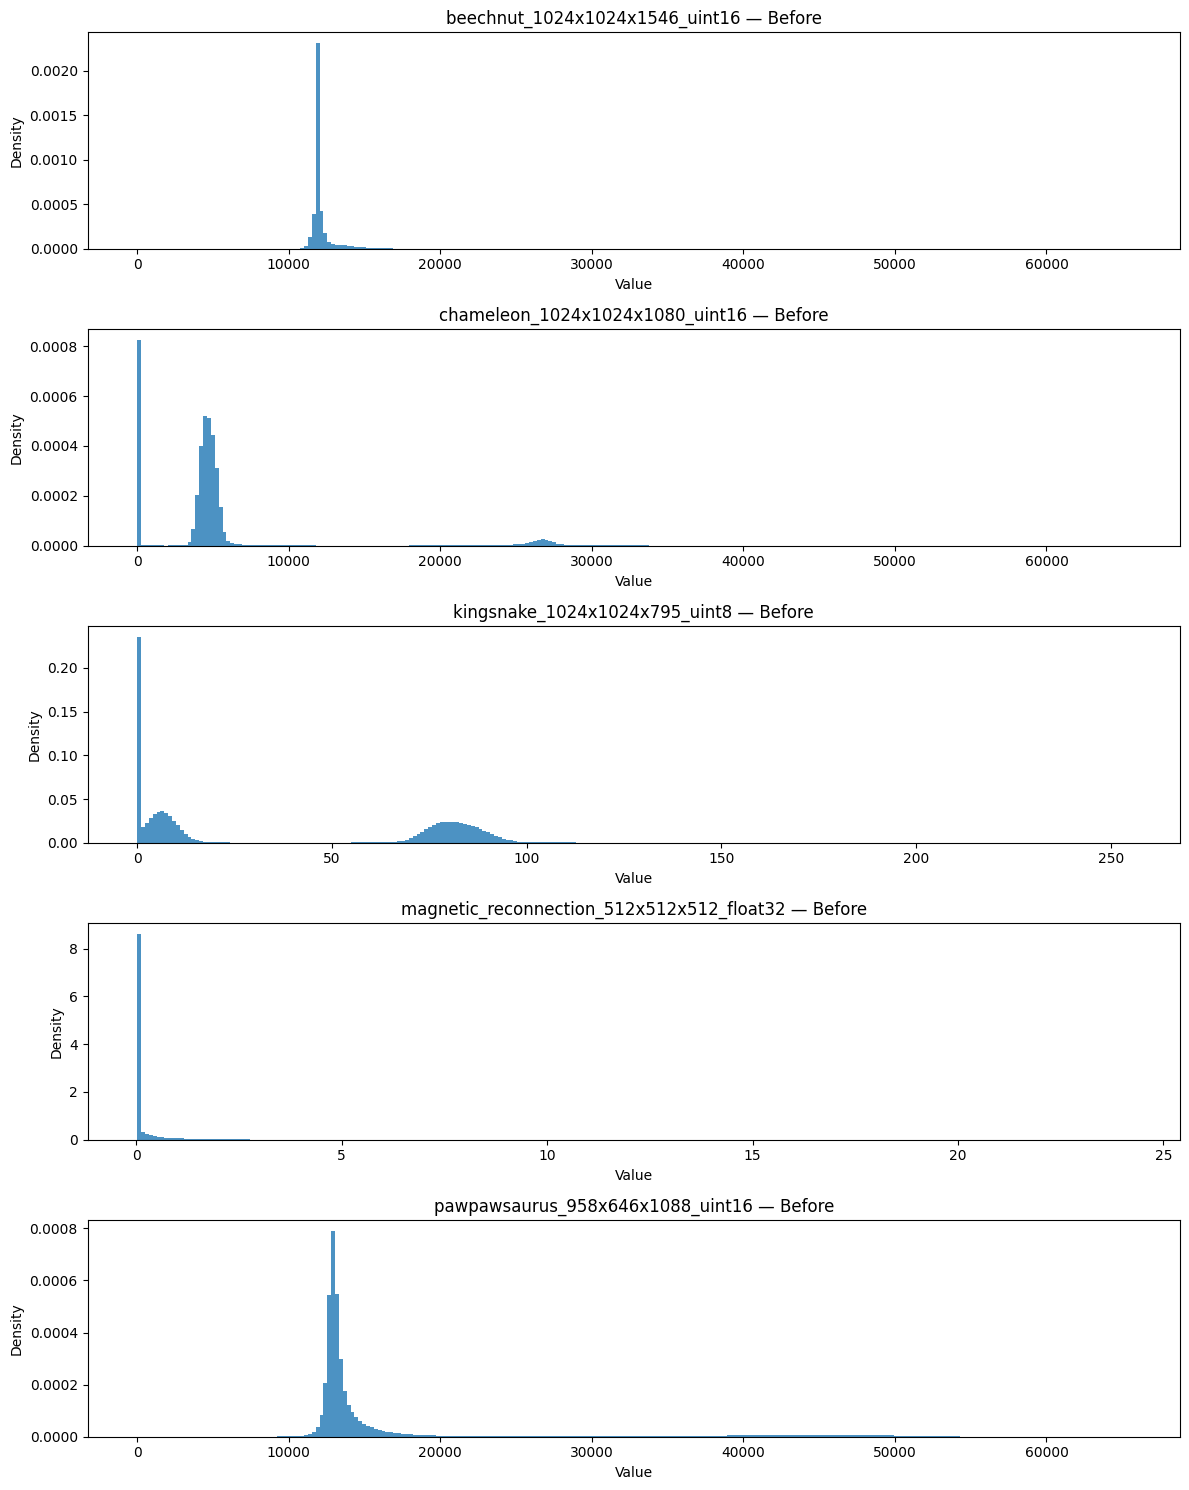

In [2]:
# Plot histograms for each set (one row per set: before | after)
import matplotlib.pyplot as plt
from pathlib import Path

if 'sets' not in globals():
    raise RuntimeError("`sets` not found - run the cell that builds `sets` first")

n_sets = len(sets)
if n_sets == 0:
    print("No sets to plot.")
else:
    fig, axes = plt.subplots(n_sets, 1, figsize=(12, max(3, 3 * n_sets)), squeeze=False)
    for i, (name, data) in enumerate(sets.items()):
        before = data.flatten()

        # Use a shared range per row so before/after are comparable
        vmin = float(before.min())
        vmax = float(before.max())

        bins = 256
        axes[i, 0].hist(before, bins=bins, range=(vmin, vmax), density=True, color='C0', alpha=0.8)
        axes[i, 0].set_title(f"{name} — Before")
        axes[i, 0].set_ylabel('Density')

        # Labels
        axes[i, 0].set_xlabel('Value')

        # Print basic stats for quick inspection
        print(f"{name}: before mean={before.mean():.4f}, std={before.std():.4f}")

    plt.tight_layout()
    plt.show()